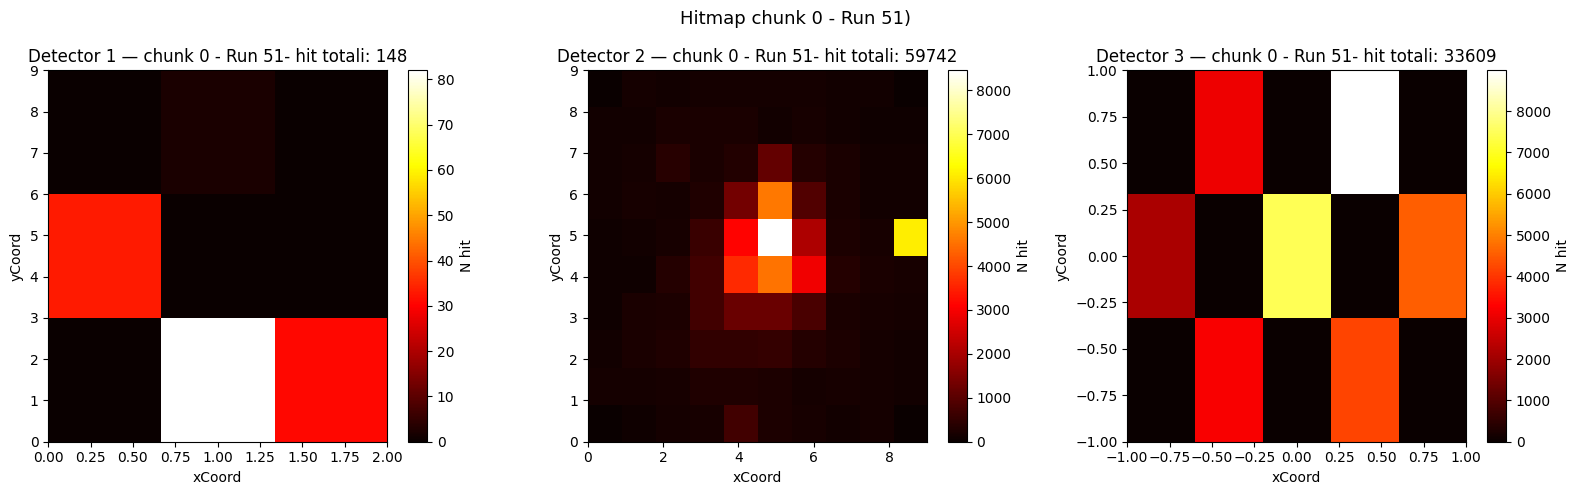

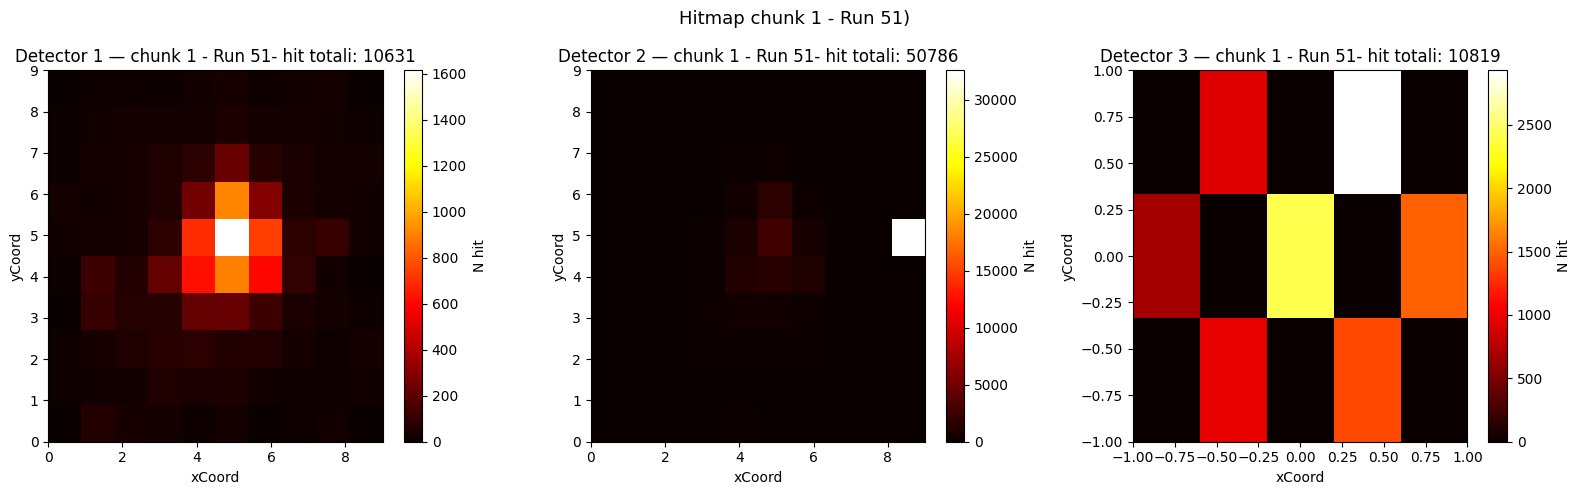

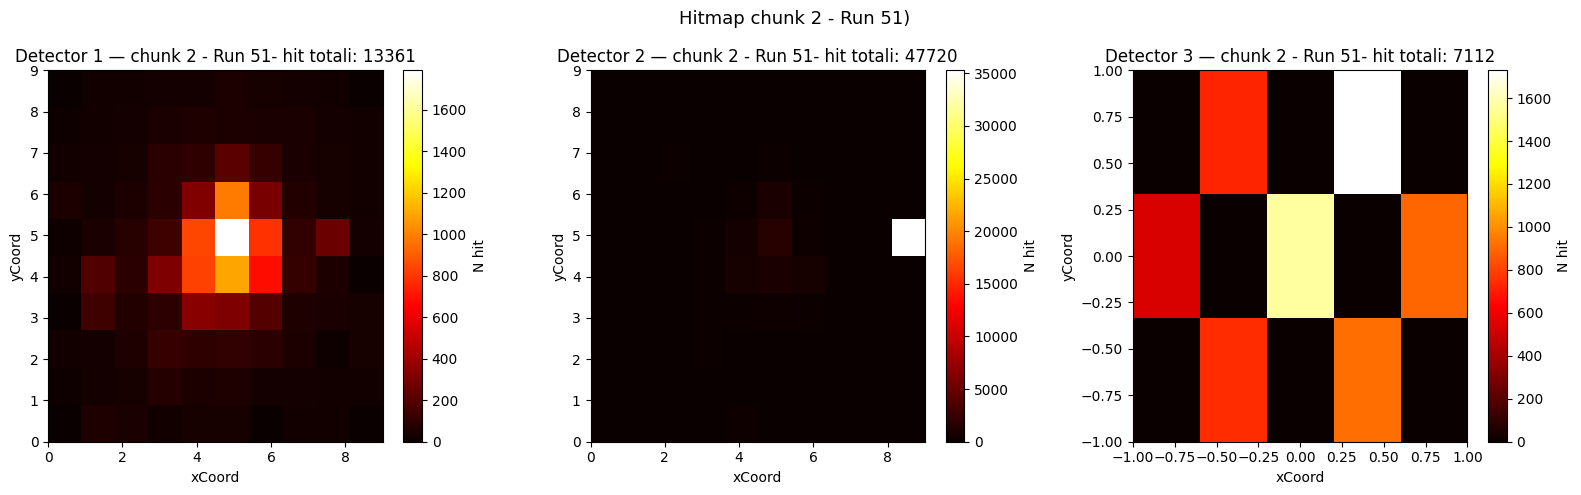

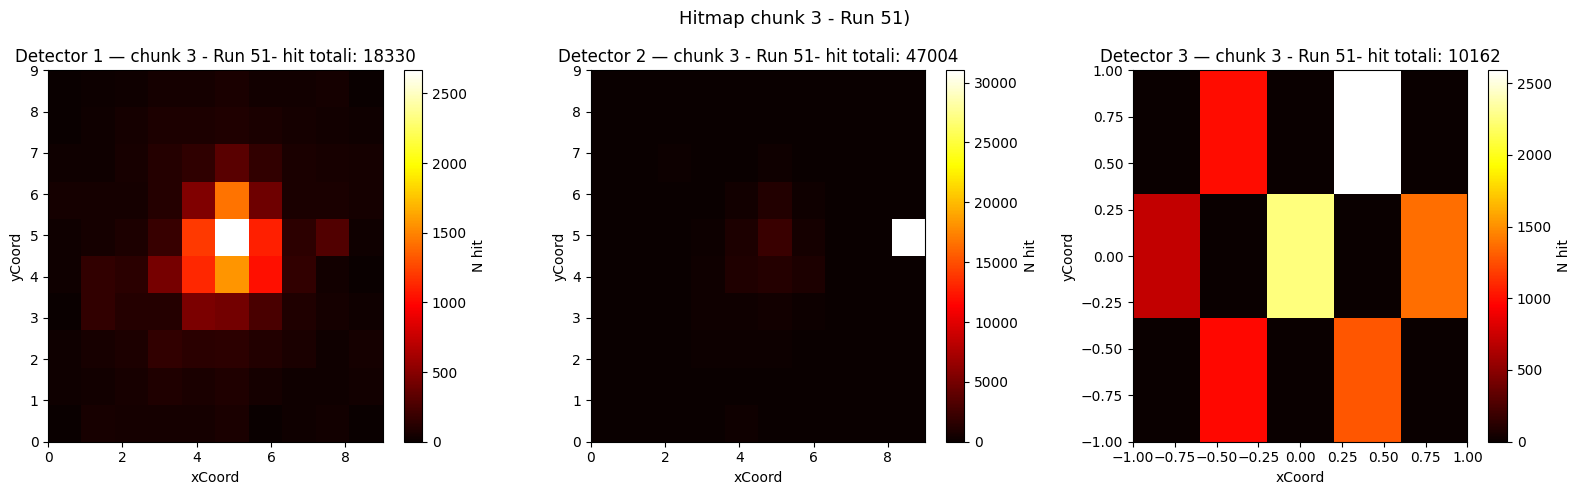

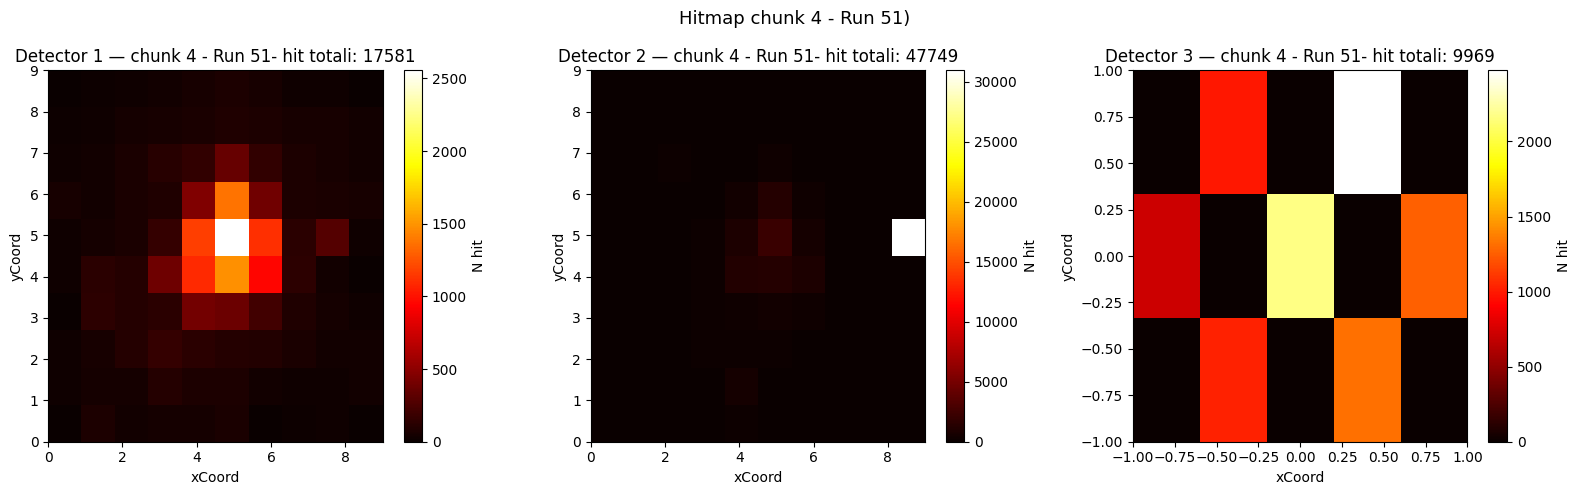

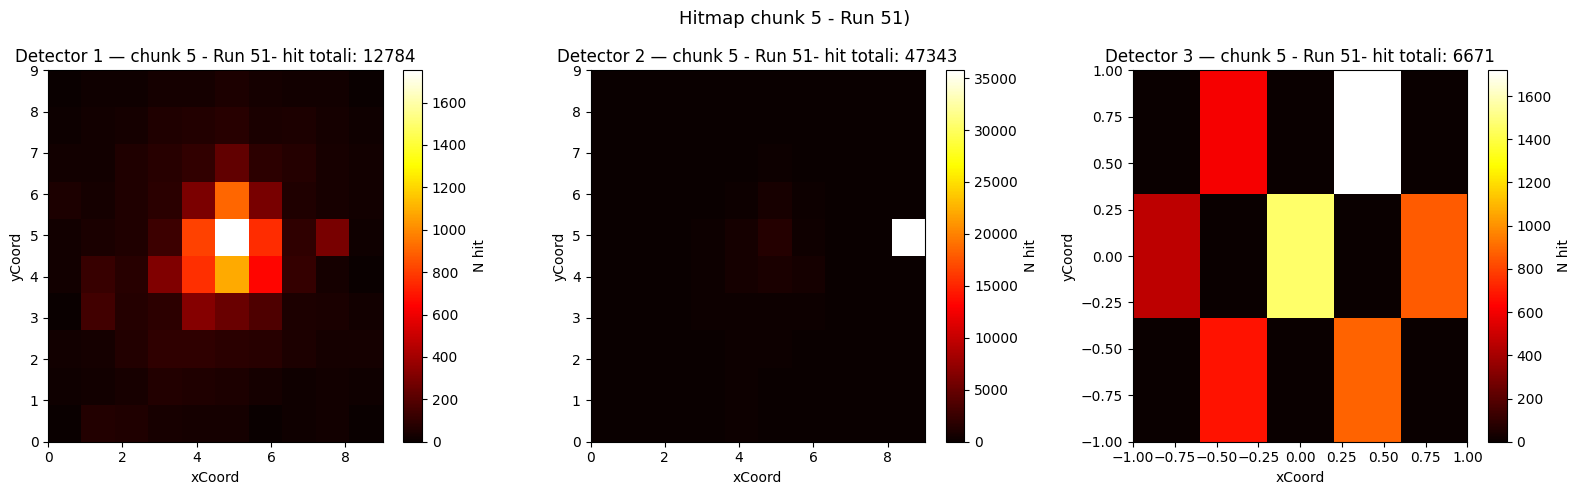

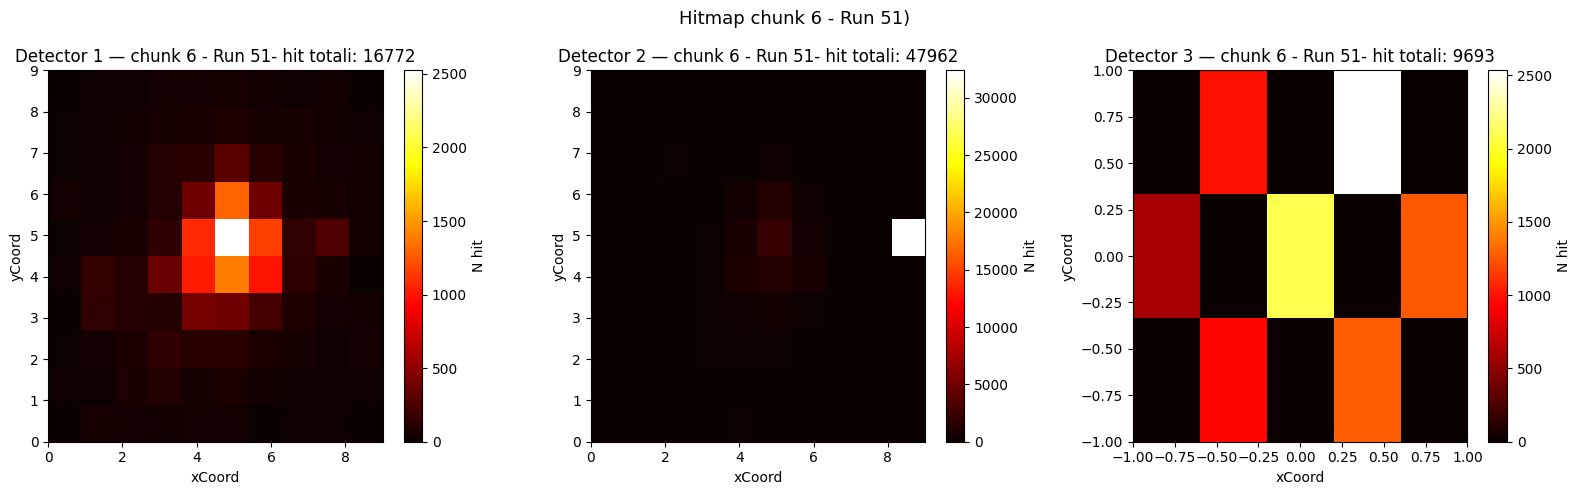

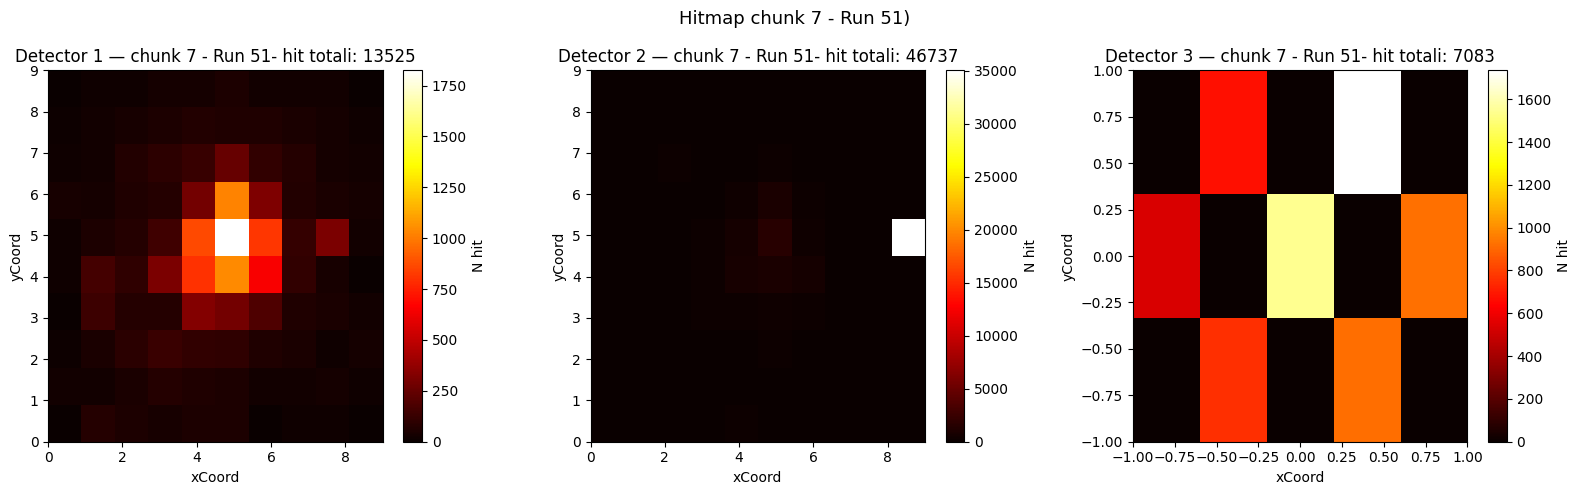

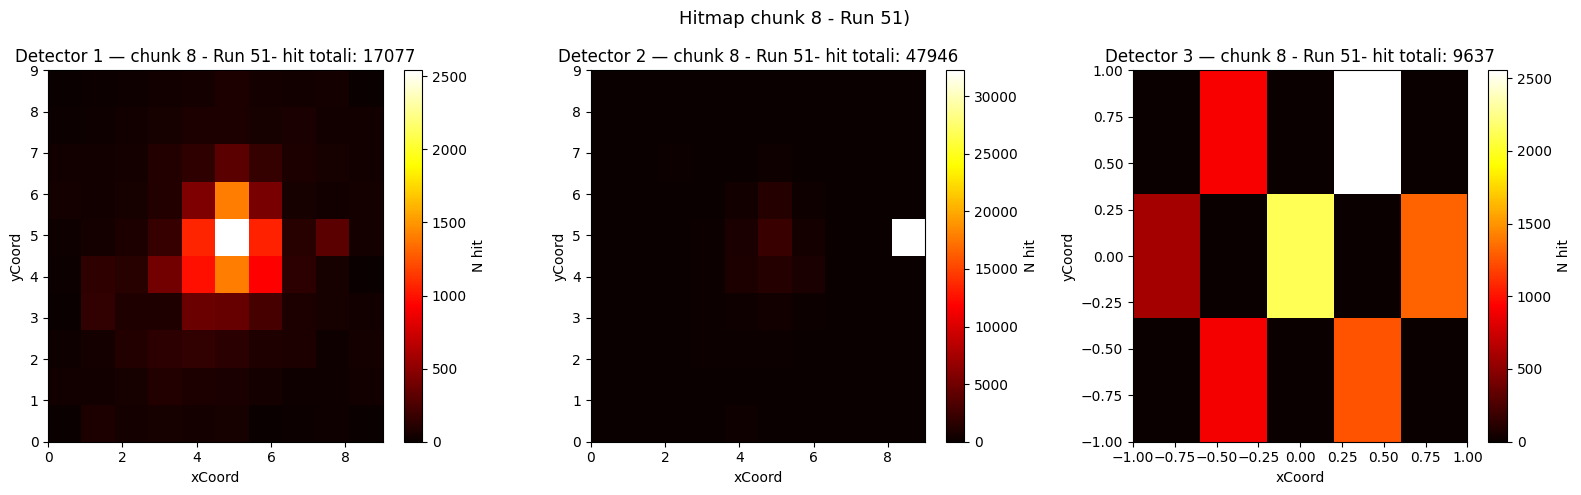

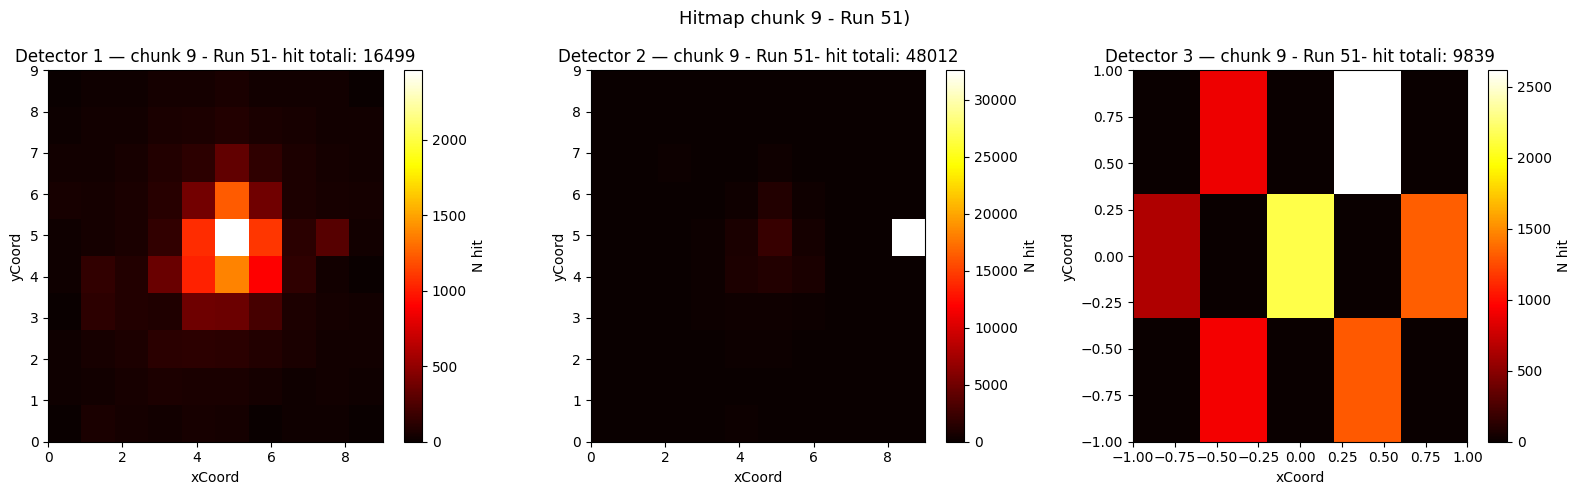

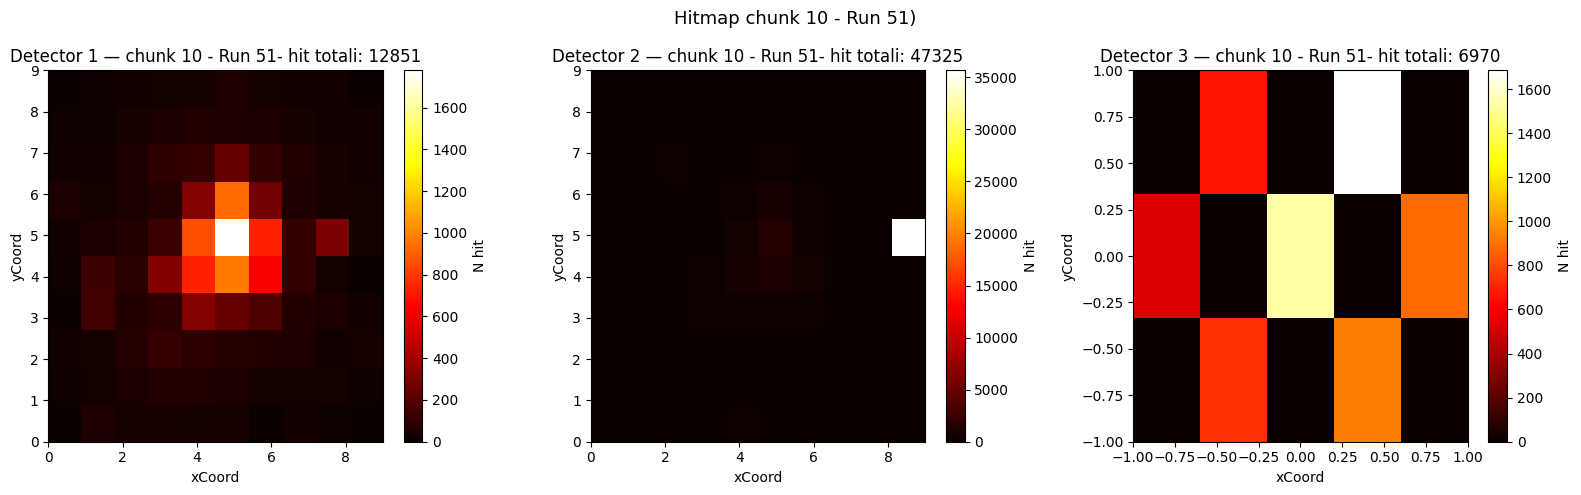

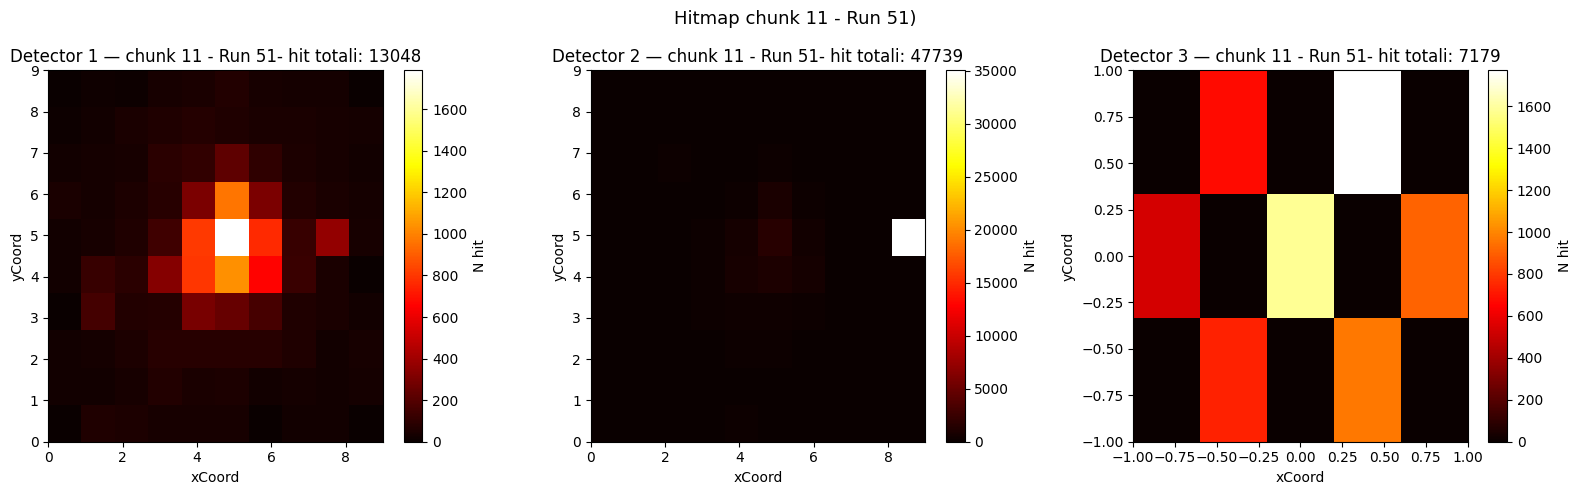

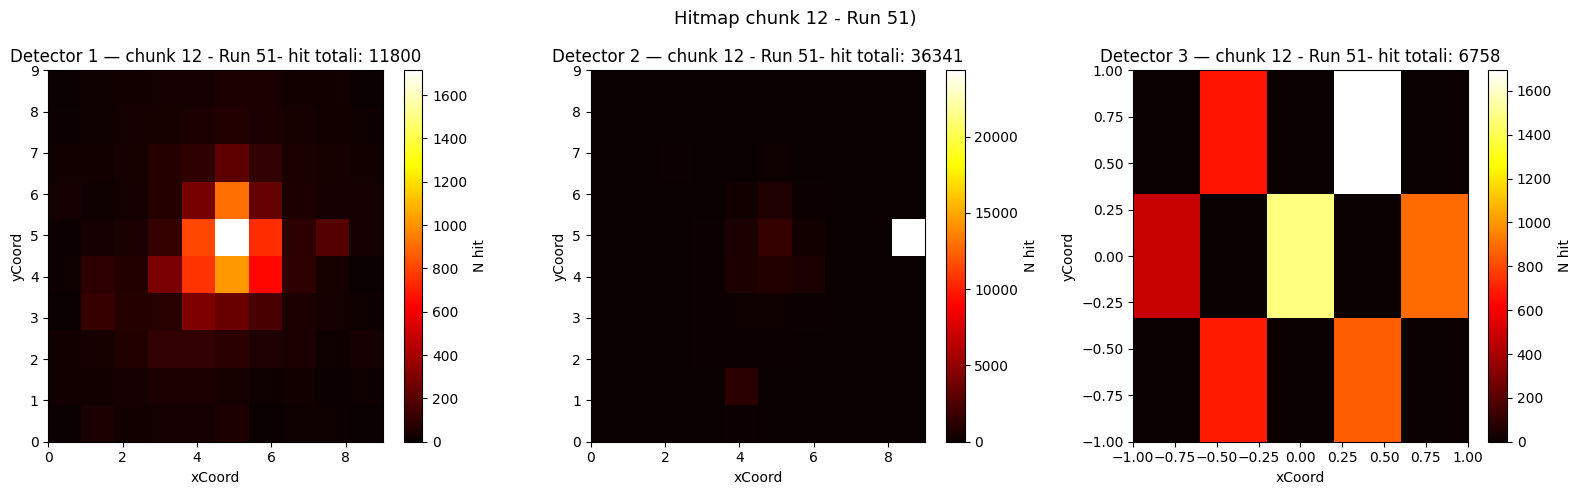

In [ ]:
import uproot
import numpy as np
import matplotlib.pyplot as plt
import awkward as ak
run_number=51 
with uproot.open(f"~/Scrivania/sampic_run{run_number}_merged.root") as file:
    tree = file["picoTree"]

    # Loop su tutti i chunk
    for chunk_id, chunk in enumerate(tree.iterate(
        ['Detector', 'Channel', 'Multiplicity', 'ArraySize', 'xCoord', 'yCoord', 'Cell0TimeStamp'],
        library="ak",
        step_size=50_000
    )):

        det        = ak.to_numpy(chunk['Detector'])
        mult       = ak.to_numpy(chunk['Multiplicity'])
        array_size = ak.to_numpy(chunk['ArraySize'])
        xcoord     = ak.to_numpy(chunk['xCoord'])
        ycoord     = ak.to_numpy(chunk['yCoord'])
        Cell0TimeStamp = ak.to_numpy(chunk['Cell0TimeStamp'])

        # --- Hitmap per detector ---
        fig, axes = plt.subplots(1, 3, figsize=(16, 5))

        for i, det_id in enumerate([1, 2, 3]):

            x_hits = []
            y_hits = []

            for evt in range(len(array_size)):
                n_hit = array_size[evt]

                for hit in range(n_hit):

                    if det[evt, hit] == det_id:
                        x_hits.append(xcoord[evt, hit])
                        y_hits.append(ycoord[evt, hit])

            if len(x_hits) == 0:
                axes[i].set_title(f"Detector {det_id} — nessuna hit")
                axes[i].axis('off')
                continue

            x_hits = np.array(x_hits)
            y_hits = np.array(y_hits)

            # Valori unici coordinate
            x_unique = np.sort(np.unique(x_hits))
            y_unique = np.sort(np.unique(y_hits))

            # Costruisci hitmap
            hitmap = np.zeros((len(y_unique), len(x_unique)))

            for x, y in zip(x_hits, y_hits):
                ix = np.where(x_unique == x)[0][0]
                iy = np.where(y_unique == y)[0][0]
                hitmap[iy, ix] += 1

            im = axes[i].imshow(
                hitmap,
                origin='lower',
                aspect='auto',
                extent=[
                    x_unique[0], x_unique[-1],
                    y_unique[0], y_unique[-1]
                ],
                cmap='hot'
            )

            plt.colorbar(im, ax=axes[i], label='N hit')

            axes[i].set_xlabel("xCoord")
            axes[i].set_ylabel("yCoord")
            axes[i].set_title(
                f"Detector {det_id} — chunk {chunk_id} - Run {run_number}- hit totali: {len(x_hits)}"
            )

        plt.suptitle(f"Hitmap chunk {chunk_id} - Run {run_number})", fontsize=13)
        plt.tight_layout()
        plt.show()